# Single-cell analysis: LiFi 1.0 (LED) vs LiFi 2.0 (VCSEL)

This notebook implements a single-cell analysis for the comparative study between LiFi 1.0 and LiFi 2.0. It is divided into two stages because each one answers a different question.

**Phase 1** investigates how the channel models differ when both technologies operate under the same conditions: identical transmit power and an identical receiver. The channel gain is analyzed in two steps: first without the receiver field of view (what each source can cover by itself) and then with the receiver FoV applied.

**Phase 2** investigates how both technologies perform under realistic operating conditions. In this case, each transmitter operates within its own practical constraints, allowing the impact of illumination and eye-safety requirements to be evaluated.

Every paper cited in this notebook is stored in the [`sources/`](sources/) folder.

**Table of contents**

- [Parameters used in this notebook](#Parameters-used-in-this-notebook)
- [1. References](#1.-References)
- [2. Common scenario](#2.-Common-scenario)
- [3. Phase 1 - Single-cell channel comparison](#3.-Phase-1---Single-cell-channel-comparison)
    - [3.1 Channel models and receiver FoV](#3.1-Channel-models-and-receiver-FoV)
    - [3.2 Source-only channel gain (without receiver FoV)](#3.2-Source-only-channel-gain-(without-receiver-FoV))
    - [3.3 Channel-gain maps with the receiver FoV applied](#3.3-Channel-gain-maps-with-the-receiver-FoV-applied)
    - [3.4 Radial profile](#3.4-Radial-profile)
    - [3.5 Received power, SNR and achievable rate at the normalization power](#3.5-Received-power,-SNR-and-achievable-rate-at-the-normalization-power)
    - [3.6 Coverage vs. SNR threshold](#3.6-Coverage-vs.-SNR-threshold)
    - [3.7 Phase 1 discussion](#3.7-Phase-1-discussion)
- [4. Phase 2 - Realistic single-cell analysis](#4.-Phase-2---Realistic-single-cell-analysis)
    - [4.1 LiFi 1.0 power - illuminance requirement](#4.1-LiFi-1.0-power---illuminance-requirement)
    - [4.2 LiFi 2.0 power - eye safety IEC 60825-1](#4.2-LiFi-2.0-power---eye-safety-IEC-60825-1)
        - [4.2.1 Choosing a physically consistent beam waist](#4.2.1-Choosing-a-physically-consistent-beam-waist)
        - [4.2.2 Sensitivity to the beam waist](#4.2.2-Sensitivity-to-the-beam-waist)
    - [4.3 Coverage under realistic power](#4.3-Coverage-under-realistic-power)
    - [4.4 Summary table and energy efficiency](#4.4-Summary-table-and-energy-efficiency)
    - [4.5 Spectral consideration - wavelength-dependent responsivity](#4.5-Spectral-consideration---wavelength-dependent-responsivity)
    - [4.6 Sensitivity to the receiver FoV and the coverage threshold](#4.6-Sensitivity-to-the-receiver-FoV-and-the-coverage-threshold)
- [5. Interpretation](#5.-Interpretation)
    - [5.1 From a single VCSEL to an array](#5.1-From-a-single-VCSEL-to-an-array)
    - [5.2 Scaling analysis: equivalent optical power from multiple VCSELs](#5.2-Scaling-analysis:-equivalent-optical-power-from-multiple-VCSELs)
    - [5.3 Summary: LiFi 1.0 vs LiFi 2.0 at a glance](#5.3-Summary:-LiFi-1.0-vs-LiFi-2.0-at-a-glance)
- [6. Transition to the multi-cell analysis](#6.-Transition-to-the-multi-cell-analysis)

## Parameters used in this notebook

These are the main parameters that are used in this analysis:

**The room and the devices**

| Parameter | Name | What it means | Value |
|:---|:---|:---|:---|
| `ROOM_X`, `ROOM_Y` | Room dimensions | Size of the room floor | 5 m x 5 m |
| `TX_HEIGHT` | Transmitter height | Height of the transmitter (LED or VCSEL), on the ceiling | 3 m |
| `RX_HEIGHT` | Receiver height | Height of the receiver, like a desk | 1 m |
| `theta` | Incidence / irradiance angle | Angle between "straight up" and the line joining Tx and Rx: 0 deg directly below the Tx, larger toward the edges | derived |
| `APD` | Photodetector active area | Size of the light-sensing area on the receiver | 1 cm^2 |
| `RHO` | Photodetector responsivity | How much electrical current comes out per watt of light in | 1 A/W (ideal baseline) |

**LiFi 1.0: LED**

| Parameter | Name | What it means | Value |
|:---|:---|:---|:---|
| `PHI_HALF_DEG` | LED half-power semiangle | How wide the LED's light cone is (bigger = more spread out, like a lamp) | 80 deg |
| `m_led` | Lambertian order | Number describing how focused the LED beam is, calculated from the angle above | derived |

**LiFi 2.0: VCSEL (laser)**

| Parameter | Name | What it means | Value |
|:---|:---|:---|:---|
| `W0` | Beam waist | How narrow the laser beam is right at the source | 5 micrometers (see Section 4.2.1 for why) |
| `LAMBDA` | Wavelength | Color of the laser light | 950 nm (infrared, invisible) |
| `zR` | Rayleigh range | Distance over which the beam stays roughly as narrow as at the source, before it starts visibly spreading out | derived |

**The receiver's "field of view"**

| Parameter | Name | What it means | Value |
|:---|:---|:---|:---|
| `PSI_C_DEG` | Receiver FoV semiangle | How wide an angle the receiver can "see" light from, like a camera's field of view | 40 deg |
| `N_LENS` | Concentrator refractive index | Refractive index of the small lens (concentrator) placed in front of the receiver to collect extra light | 1.5 |
| `G_CONC` | Concentrator gain | How much the concentrator lens boosts the signal for light arriving inside the FoV | derived |
| `r_fov` | FoV footprint radius | Radius, on the desk plane, of the circle the receiver can actually "see" | derived |

**Signal quality and speed**

| Parameter | Name | What it means | Value |
|:---|:---|:---|:---|
| `N0` | Noise power spectral density | Amount of background electronic noise the receiver has to fight against | fixed value |
| `B1`, `B2` | Bandwidth | How fast each technology could go  | 20 MHz (LED) / 2 GHz (VCSEL) |
| `PTX_NORM` | Normalization transmit power | A shared, made-up transmit power used only in Phase 1, so both technologies are compared on equal terms | 1 W |

**Phase 2**

| Parameter | Name | What it means | Value |
|:---|:---|:---|:---|
| `E_TARGET_LUX` | Illuminance target | How bright the room needs to be for people to work comfortably (an office lighting standard) | 500 lux |
| `PTX_LED_REALISTIC` | Realistic LED transmit power | LED power actually needed to reach that brightness target | derived |
| `PTX_VCSEL_EYESAFE` | Eye-safe transmit power (theoretical ceiling) | The most power a VCSEL laser could use without being a safety hazard to human eyes | derived |
| `PTX_VCSEL_EXPERIMENTAL` | Experimental transmit power | A real transmit power used in a published VCSEL experiment, kept as a sanity check | 5 mW |
| `GAMMA_TH_DB` | Coverage SNR threshold | The signal-quality bar a point in the room must clear to count as "covered" | 20 dB |
| `N_VCSEL_LIST` | VCSEL array size | How many VCSELs are grouped together, to see whether a "team" of lasers can catch up to one LED | 1 to 64 |

**Eye safety (Section 4.2)**

| Parameter | Name | What it means | Value |
|:---|:---|:---|:---|
| `MPE` | Maximum Permissible Exposure | The highest light intensity still considered safe for the human eye, set by the IEC 60825-1 standard | derived from wavelength |
| `theta_div` | Beam divergence angle | How quickly the laser beam spreads out as it travels away from the source | derived |
| `rp` | Pupil radius | Worst-case (dilated) size of a human pupil, used as the "target" the laser must not overexpose | 3.5 mm |
| `zhaz` | Hazard distance | The distance at which the eye-safety limit is actually evaluated | derived |
| `eta` | Pupil capture fraction | Fraction of the laser beam's power that could enter an eye's pupil at the hazard distance | derived |

Everything else in the notebook (`H_led`, `H_vcsel`, `SNR_...`, `R_...`, etc.) is calculated from these parameters.

## 1. References

| Key | Paper | Used for |
|---|---|---|
| `[RIS-VLC]` | [Resource Allocation Exploiting Reflective Surfaces to Minimize the Outage Probability in VLC](<sources/Resource_Allocation_Exploiting_Reflective_Surfaces_to_Minimize_the_Outage_Probability_in_VLC%20(1).pdf>) | LiFi 1.0 Lambertian LOS channel — eq. (1); optical power → illuminance — eq. (25); SNR — eq. (12); FoV coverage radius — eq. (11); parameters ($K_{e/v}$, FoV, $B$, $N_0$) — Table III |
| `[VCSEL-Precoding]` | Safi et al., [Energy-Efficient Precoding for Dense VCSEL-Based OWC Systems Under a Cooperative Broadcast Model](<sources/Energy-Efficient_Precoding_for_Dense_VCSEL-Based_OWC_Systems_Und.pdf>) | LiFi 2.0 single-VCSEL Gaussian-beam channel — eqs. (2)–(8); non-imaging concentrator gain (Kahn–Barry model), applied here to the receiver of *both* technologies — eq. (8); parameters ($w_0$, $\lambda$, $n$, $A_{PD}$, $\rho$, $B$) — Table I |
| `[Capacity-Bound]` | Wang et al., [Tight Bounds on Channel Capacity for Dimmable Visible Light Communications](<sources/TightBoundsonChannelCapacityforDimmableVisibleLightCommunications.pdf>) | Achievable-rate lower bound for both technologies — eq. (37) (cited as [39] in `[RIS-VLC]` and [31] in `[VCSEL-Precoding]`) |
| `[Eye-Safety]` | Soltani et al., [Safety Analysis for Laser-Based Optical Wireless Communications: A Tutorial](<sources/Safety_Analysis_for_Laser-Based_Optical_Wireless_Communications_A_Tutorial.pdf>) | Max eye-safe CW power of a single-mode VCSEL — Algorithm 1, eq. (36), divergence eq. (8); IEC 60825-1:2014 near-IR MPE — Table 4 |
| `[VCSEL-70Gbps]` | Kazemi et al. 2025, [Achieving 70 Gb/s Over a VCSEL-Based Optical Wireless Link Using a Multi-Mode Fiber-Coupled Receiver](<sources/achieving_70gbs_vcsel_wirelesslink_multimodefiber.pdf>) | Experimental single-VCSEL operating power (~5 mW, 940 nm) as an eye-safety cross-check — Table I / abstract |


----

## 2. Common scenario

Everything here stays the same across both phases and both technologies: the room, the ceiling/desk height, the transmitter position, the photodetector, and the receiver grid. The only parameters that change later on are the ones related to channel model (Phase 1) and the transmit power (Phase 2).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# room and tx/rx geometry, shared by every cell in the code below 

ROOM_X, ROOM_Y = 5.0, 5.0 # room floor size [m], typical attocell footprint
TX_HEIGHT = 3.0 # tx height, mounted on the ceiling [m]
RX_HEIGHT = 1.0 # rx height, desk level [m]

TX_POS = np.array([ROOM_X / 2, ROOM_Y / 2, TX_HEIGHT]) # tx at the center of the ceiling
dz = TX_HEIGHT - RX_HEIGHT # vertical tx-rx separation [m]

APD = 1e-4 # photodetector active area A_PD [m^2] = 1 cm^2 ([RIS-VLC] Table III / [VCSEL-Precoding] Table I)
RHO = 1.0 # photodetector responsivity rho [A/W], same in both papers (see Section 4.5)

# receiver grid: N x N points covering the whole floor
N = 300
xs = np.linspace(0, ROOM_X, N)
ys = np.linspace(0, ROOM_Y, N)
X, Y = np.meshgrid(xs, ys)

r0 = np.sqrt((X - TX_POS[0])**2 + (Y - TX_POS[1])**2) # horizontal distance from tx to each rx point [m]
d3d = np.sqrt(r0**2 + dz**2) # straight-line tx-rx distance [m]
theta = np.arctan2(r0, dz) # irradiance/incidence angle seen from tx [rad]

print(f"Room {ROOM_X:.0f}x{ROOM_Y:.0f}x{TX_HEIGHT:.0f} m")
print(f"Tx-Rx vertical separation = {dz:.1f} m")

Room 5x5x3 m
Tx-Rx vertical separation = 2.0 m


## 3. Phase 1: Single-cell channel comparison

In this phase, everything is kept constant except the channel model: same room, same Tx/Rx geometry, same $A_{PD}$ and $\rho$, same treatment of the receiver FoV, and both transmitters send the same normalization power, $P_{tx} = 1\,\text{W}$

The 1 W value is set just so both technologies are compared under the exact same conditions.

### 3.1 Channel models and receiver FoV

Both technologies model the direct line-of-sight channel gain $H$ as a function of the horizontal distance $r_0$, the vertical separation $\Delta z$, the straight-line distance $d=\sqrt{r_0^2+\Delta z^2}$, and the incidence angle $\theta=\arctan(r_0/\Delta z)$ (see [Parameters used in this notebook](#Parameters-used-in-this-notebook)).

**LiFi 1.0: LED, Lambertian source (`[RIS-VLC]` eq. (1)):**

$$H_{LED}(\theta) = \frac{(m+1)\,A_{PD}}{2\pi d^2}\cos^{m}(\theta)\cos(\theta), \qquad m = \frac{-1}{\log_2\left(\cos(\Phi_{1/2})\right)}$$

$\Phi_{1/2}$ is the LED's half-power semiangle and $m$ is the Lambertian order: a wider $\Phi_{1/2}$ gives a smaller $m$, that is: a broader, flatter beam.

**LiFi 2.0: VCSEL, Gaussian beam (`[VCSEL-Precoding]` eqs. (2)-(7)):**

$$z_R=\frac{\pi w_0^2}{\lambda}, \qquad w(d)=w_0\sqrt{1+\left(\frac{d}{z_R}\right)^2}, \qquad H_{VCSEL}(r_0,d) = \frac{2\,A_{PD}}{\pi\,w(d)^2}\exp\!\left(\frac{-2r_0^2}{w(d)^2}\right)$$

$z_R$ is the Rayleigh range and $w(d)$ is the beam radius at distance $d$: close to the source the beam stays roughly $w_0$-wide, then widens once $d$ grows past $z_R$.

The **receiver side** is identical for both technologies. The field of view (FoV) is a property of the receiver, not the transmitter. Therefore, the FoV must be identical for both technologies if we want to have a fair comparison:

- The reference papers use different semiangles (40° in `[RIS-VLC]` and 60° in `[VCSEL-Precoding]`) simply because they assume different receiver designs. However, keeping different values would mean comparing two different receivers rather than the transmitters.

- We use a single receiver model for both cases: a photodiode with an area of $A_{PD} = 1\,\text{cm}^2$ and an optical concentrator (refractive index $n = 1.5$ and acceptance semiangle $\Psi_c = 40°$, taken from `[RIS-VLC]`). It follows the standard Kahn–Barry model: gain $G = n^2/\sin^2\Psi_c$ for incidence angles within the FoV, and zero otherwise.

- Applying this gain $G$ to the Lambertian channel is the only change to the original `[RIS-VLC]` equation (which originally did not have a concentrator). This is done so that the receiver is the same for both cases. 

- We assume the receiver is pointing straight up. Since moving the device would shift the coverage area, we split the analysis: Section 3.2 shows the channel gain without the FoV restriction (the raw coverage capability of each source), and Section 3.3 applies the receiver FoV restriction.

In [2]:
# LiFi 1.0: LED, Lambertian, LOS only

# Channel model [RIS-VLC] eq. (1):  H_LoS = (m+1)*A_PD/(2*pi*d^2) * cos^m(phi) * cos(psi),  0 <= psi <= Psi

# Lambertian order  [RIS-VLC] eq. (1):  m = -1 / log2(cos(phi_1/2))

PHI_HALF_DEG = 80.0  # LED half-power semiangle [deg], [RIS-VLC] Table III
m_led = -1.0 / np.log2(np.cos(np.deg2rad(PHI_HALF_DEG)))  # Lambertian order

# emitter points down and rx points up => irradiance angle phi = incidence angle psi = theta
H_led_src = (m_led + 1) * APD / (2 * np.pi * d3d**2) * np.cos(theta)**m_led * np.cos(theta)

In [3]:
# LiFi 2.0: single VCSEL, Gaussian beam ([VCSEL-Precoding], Safi et al., eqs. (2)-(8))

W0 = 5e-6    # beam waist w0 at the VCSEL aperture [m]
# wo = 5um

LAMBDA = 950e-9 # VCSEL wavelength lambda [m], [VCSEL-Precoding] Table I
# lambda = 950 nm (IR)

zR = np.pi * W0**2 / LAMBDA  # Rayleigh range of the beam [m], [VCSEL-Precoding] eq. (2)
wz = W0 * np.sqrt(1 + (d3d / zR)**2) # beam radius at distance d3d [m], [VCSEL-Precoding] eq. (6)
Z_irr = 2 / (np.pi * wz**2) * np.exp(-2 * r0**2 / wz**2) # Gaussian irradiance profile, [VCSEL-Precoding] eq. (7)
H_vcsel_src = Z_irr * APD # source-only VCSEL gain (PD, no concentrator)

In [4]:
# Receiver side: unified PD + concentrator, identical for BOTH 

PSI_C_DEG = 40.0  # receiver FoV semiangle Psi_c [deg], same for both technologies ([RIS-VLC] Table III lists 30/40/50)
N_LENS = 1.5  # concentrator refractive index n, [VCSEL-Precoding] eq. (8)

PSI_C = np.deg2rad(PSI_C_DEG)
G_CONC = N_LENS**2 / np.sin(PSI_C)**2  # non-imaging concentrator gain G, [VCSEL-Precoding] eq. (8) (Kahn-Barry)
in_fov = theta <= PSI_C # unified receiver FoV mask (receiver pointing straight up)
r_fov = dz * np.tan(PSI_C) # FoV footprint radius on the desk plane [m], [RIS-VLC] eq. (11)

# full channel gain = source shape x concentrator gain, zero outside the receiver FoV
H_led = np.where(in_fov, H_led_src * G_CONC, 0.0)
H_vcsel = np.where(in_fov, H_vcsel_src * G_CONC, 0.0)

print(f"m_led = {m_led:.3f}")
print(f"Unified receiver: Psi_c = {PSI_C_DEG:.0f} deg -> G_conc = {G_CONC:.3f}")
print(f"Receiver FoV footprint radius on the desk plane: {r_fov:.2f} m (same for both technologies)")
print(f"VCSEL beam radius on the desk plane: w(dz) = {W0*np.sqrt(1+(dz/zR)**2):.2f} m")

m_led = 0.396
Unified receiver: Psi_c = 40 deg -> G_conc = 5.446
Receiver FoV footprint radius on the desk plane: 1.68 m (same for both technologies)
VCSEL beam radius on the desk plane: w(dz) = 0.12 m


### 3.2 Source-only channel gain (without receiver FoV)

Before applying any receiver constraints, these maps show the gain each source delivers to the desk plane. This represents what a simple, upward-facing photodiode would receive without a concentrator or angular cut-off, showing the true coverage capability of each source independently of the user's receiver setup.

**Notes from the maps**
* **No cut-offs:** The LED illuminates the entire room with a smooth Lambertian decay, and the Gaussian beam stays positive everywhere. Without receiver FoV limits, both sources reach the whole floor—just with very different intensity distributions.

* **The LED is highly uniform:** The gain varies by only about 10 dB from the center of the room to the corners, meaning the Lambertian pattern spreads the power almost evenly.

* **The VCSEL concentrates the power into a tiny spot:** almost all of it lands within roughly 1% of the room's floor area around the beam axis (a spot only about 12 cm across at the desk plane); a short distance away the signal is not just weaker, it is genuinely negligible, unlike the LED's slow, room-wide decay.

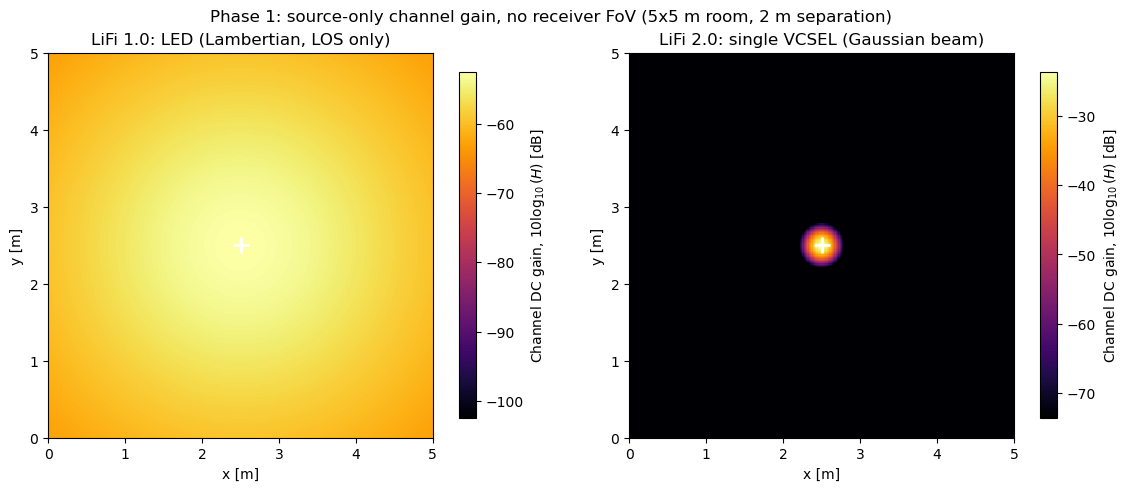

LED source-only gain: center = -52.6 dB, corner = -63.0 dB (drop = 10.4 dB)
VCSEL source-only gain: center = -23.7 dB, corner = -1828.8 dB (drop = 1805.1 dB)


In [5]:
H_led_src_dB = 10 * np.log10(H_led_src)      # source-only gains are strictly positive, so no masking needed
H_vcsel_src_dB = 10 * np.log10(H_vcsel_src)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
maps_src = [(H_led_src_dB,   "LiFi 1.0: LED (Lambertian, LOS only)"),
            (H_vcsel_src_dB, "LiFi 2.0: single VCSEL (Gaussian beam)")]

for ax, (H_dB, title) in zip(axes, maps_src):
    vmax = np.nanmax(H_dB)
    im = ax.pcolormesh(X, Y, H_dB, shading="auto", cmap="inferno", vmin=vmax - 50, vmax=vmax)
    ax.plot(*TX_POS[:2], "w+", markersize=12, mew=2)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(0, ROOM_X)
    ax.set_ylim(0, ROOM_Y)
    fig.colorbar(im, ax=ax, label=r"Channel DC gain, $10\log_{10}(H)$ [dB]", shrink=0.9)
fig.suptitle("Phase 1: source-only channel gain, no receiver FoV "
             f"({ROOM_X:.0f}x{ROOM_Y:.0f} m room, {dz:.0f} m separation)")
plt.show()

print(f"LED source-only gain: center = {H_led_src_dB.max():.1f} dB, "
      f"corner = {H_led_src_dB.min():.1f} dB (drop = {H_led_src_dB.max()-H_led_src_dB.min():.1f} dB)")
print(f"VCSEL source-only gain: center = {H_vcsel_src_dB.max():.1f} dB, "
      f"corner = {H_vcsel_src_dB.min():.1f} dB (drop = {H_vcsel_src_dB.max()-H_vcsel_src_dB.min():.1f} dB)")

### 3.3 Channel-gain maps with the receiver FoV applied

Same channel shape as above, but now seen by the actual receiver: concentrator gain $G$ inside the FoV, zero outside.

A receiver only "sees" the transmitter while the incidence angle stays within its field-of-view semiangle $\Psi_c$. With the receiver pointing straight up, on the desk plane this maps to a coverage *disk* of radius

$$r_\text{FoV} = \Delta z\,\tan(\Psi_c),$$

which with $\Psi_c = 40°$ and $\Delta z = 2$ m gives $r_\text{FoV} = 1.68$ m for both technologies. Outside this disk the non-imaging concentrator gain is zero, so $H=0$ and $10\log_{10}H\to-\infty$ (in black).

**Notes from the maps**
- The difference with respect to Section 3.2 is entirely caused by the receiver: everything outside the FoV disk is cut to exactly zero (the shapes inside the disk are unchanged from 3.2), regardless of how much light the source delivers there.
- The FoV disk covers only about 35% of this 5x5 m room, which is exactly what the LED map shows once confined to the disk. The VCSEL map tells a different story: its own beam is already far narrower than the disk (about 12 cm across, against a 1.68 m disk radius), so for the VCSEL the receiver's FoV is not actually the binding limit here but the source's own directivity.

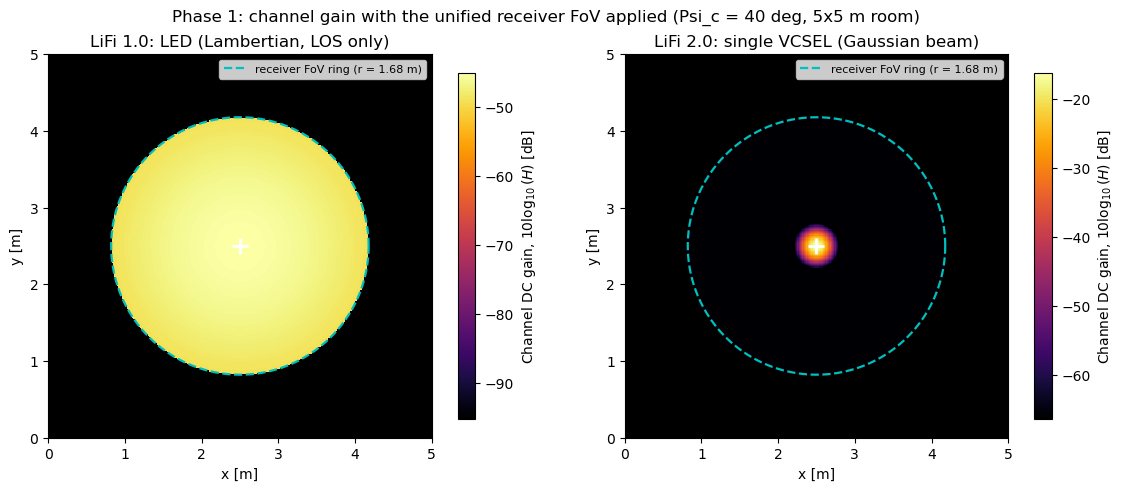

In [6]:
def to_dB(H):
    # channel gain in dB
    with np.errstate(divide="ignore"):
        return np.where(H > 0, 10 * np.log10(H), np.nan)

H_led_dB = to_dB(H_led)
H_vcsel_dB = to_dB(H_vcsel)

cmap = plt.cm.inferno.copy()
cmap.set_bad("black")  # NaN (outside the receiver FoV) rendered as true black

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
maps = [(H_led_dB,   "LiFi 1.0: LED (Lambertian, LOS only)"),
        (H_vcsel_dB, "LiFi 2.0: single VCSEL (Gaussian beam)")]
th = np.linspace(0, 2 * np.pi, 200)
for ax, (H_dB, title) in zip(axes, maps):
    vmax = np.nanmax(H_dB)
    im = ax.pcolormesh(X, Y, H_dB, shading="auto", cmap=cmap, vmin=vmax - 50, vmax=vmax)
    ax.plot(TX_POS[0] + r_fov * np.cos(th), TX_POS[1] + r_fov * np.sin(th),
            "c--", lw=1.6, label=f"receiver FoV ring (r = {r_fov:.2f} m)")
    ax.plot(*TX_POS[:2], "w+", markersize=12, mew=2)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(0, ROOM_X)
    ax.set_ylim(0, ROOM_Y)
    ax.legend(loc="upper right", fontsize=8)
    fig.colorbar(im, ax=ax, label=r"Channel DC gain, $10\log_{10}(H)$ [dB]", shrink=0.9)
fig.suptitle("Phase 1: channel gain with the unified receiver FoV applied "
             f"(Psi_c = {PSI_C_DEG:.0f} deg, {ROOM_X:.0f}x{ROOM_Y:.0f} m room)")
plt.show()

### 3.4 Radial profile

This plot shows the exact same channel gain, but sliced along a straight line moving outward from directly under the transmitter, making it much easier to compare the LED and VCSEL shapes. 

* **Thin, faded lines:** Show the raw, source-only gain (from Section 3.2).
* **Solid lines:** Include the full receiver model, adding both the concentrator gain and the FoV cut-off (from Section 3.3).

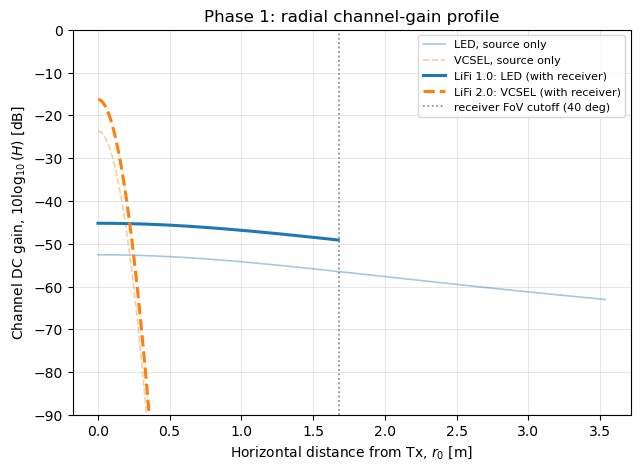

In [12]:
r0_line = np.linspace(1e-3, np.hypot(ROOM_X, ROOM_Y) / 2, 400)  # horizontal distance samples [m]
d_line = np.sqrt(r0_line**2 + dz**2)  # straight-line tx-rx distance along that line [m]
th_line = np.arctan2(r0_line, dz) # incidence angle along that line [rad]

# source-only gains along the line (same formulas as Section 3.2)
Hl_src_line = (m_led + 1) * APD / (2 * np.pi * d_line**2) * np.cos(th_line)**m_led * np.cos(th_line)
wz_line = W0 * np.sqrt(1 + (d_line / zR)**2)  # VCSEL beam radius along the line [m]
Hv_src_line = 2 / (np.pi * wz_line**2) * np.exp(-2 * r0_line**2 / wz_line**2) * APD

# receiver applied: concentrator gain inside the FoV, NaN outside so it just doesn't plot
Hl_line = np.where(th_line <= PSI_C, Hl_src_line * G_CONC, np.nan)
Hv_line = np.where(th_line <= PSI_C, Hv_src_line * G_CONC, np.nan)

fig, ax = plt.subplots(figsize=(7.2, 5))
ax.plot(r0_line, 10 * np.log10(Hl_src_line), color="tab:blue", lw=1.2, alpha=0.4, label="LED, source only")
ax.plot(r0_line, 10 * np.log10(Hv_src_line), color="tab:orange", lw=1.2, alpha=0.4, ls="--", label="VCSEL, source only")
ax.plot(r0_line, 10 * np.log10(Hl_line), color="tab:blue", lw=2.2, label="LiFi 1.0: LED (with receiver)")
ax.plot(r0_line, 10 * np.log10(Hv_line), color="tab:orange", lw=2.2, ls="--", label="LiFi 2.0: VCSEL (with receiver)")
ax.axvline(r_fov, color="gray", ls=":", lw=1.2, label=f"receiver FoV cutoff ({PSI_C_DEG:.0f} deg)")
ax.set_xlabel(r"Horizontal distance from Tx, $r_0$ [m]")
ax.set_ylabel(r"Channel DC gain, $10\log_{10}(H)$ [dB]")
ax.set_title("Phase 1: radial channel-gain profile")
ax.legend(fontsize=8)
ax.grid(alpha=.3)
ax.set_ylim(-90, 0)
plt.show()

### 3.5 Received power, SNR and achievable rate at the normalization power

For a transmit power $P_{tx}$, the received electrical SNR is (`[RIS-VLC]` eq. (12)):

$$\mathrm{SNR} = \frac{(\rho\,P_{r})^2}{N_0\,B}, \qquad P_r = P_{tx}\,H$$

The achievable rate is computed using

$$
R=\frac{B}{2}\log_2\left(1+\frac{e}{2\pi}\mathrm{SNR}\right),
$$

which is the lower bound commonly used for IM/DD systems, from `[Capacity-Bound]`. Both `[RIS-VLC]` and `[VCSEL-Precoding]` use this expression instead of the classical Shannon capacity because optical wireless communication uses intensity modulation with non-negative signals, making the standard Shannon expression less appropriate.

For the noise, we assume the same PSD $N_0$ for both technologies. The `[RIS-VLC]` paper gives a value for $N_0$, `[VCSEL-Precoding]` doesn't, so I reuse the same one for the VCSEL under the assumption that the receiver itself doesn't change. This way any difference in the results comes from the transmitter and the channel, not from an arbitrary noise choice. Even with the same $N_0$, the total noise power still differs between the two because the bandwidth is different (20 MHz for LiFi 1.0, 2 GHz for LiFi 2.0).

This is a simplification since a GHz-class receiver wouldn't really share the exact same noise characteristics as one built for a few tens of MHz; but keeping $N_0$ fixed allows to isolate the effect of the propagation model, which is the actual point of this first part.


In [13]:
N0 = 2.5e-20   # noise PSD N0 [W/Hz], [RIS-VLC] (reused for LiFi 2.0)
B1 = 20e6      # LiFi 1.0 bandwidth [Hz], [RIS-VLC] Table III
B2 = 2e9       # LiFi 2.0 bandwidth [Hz], [VCSEL-Precoding] Table I

K_BOUND = np.e / (2 * np.pi)  # constant e/(2*pi) in the rate bound, [Capacity-Bound] eq. (37)

def snr_rate(Ptx_led, Ptx_vcsel):
    Pr_led = Ptx_led * H_led # received optical power, LED [W]
    Pr_vcsel = Ptx_vcsel * H_vcsel # received optical power, VCSEL [W]
    SNR_led = (RHO * Pr_led)**2 / (N0 * B1)   
    SNR_vcsel = (RHO * Pr_vcsel)**2 / (N0 * B2)
    # achievable-rate lower bound R = (B/2)*log2(1 + (e/2pi)*SNR), [Capacity-Bound] eq. (37)
    R_led = 0.5 * B1 * np.log2(1 + K_BOUND * SNR_led)   # [bit/s]
    R_vcsel = 0.5 * B2 * np.log2(1 + K_BOUND * SNR_vcsel) # [bit/s]
    return Pr_led, Pr_vcsel, SNR_led, SNR_vcsel, R_led, R_vcsel

PTX_NORM = 1.0  # normalization power for Phase 1 [W], same for both transmitters
Pr_led1, Pr_vcsel1, SNR_led1, SNR_vcsel1, R_led1, R_vcsel1 = snr_rate(PTX_NORM, PTX_NORM)

print(f"Phase 1 @ Ptx = {PTX_NORM:.0f} W (both):")
print(f"  LiFi 1.0: peak Pr={np.nanmax(Pr_led1)*1e3:.3f} mW, peak SNR={10*np.log10(np.nanmax(SNR_led1)):.1f} dB "
      f", peak rate={np.nanmax(R_led1)/1e6:.1f} Mbit/s")
print(f"  LiFi 2.0: peak Pr={np.nanmax(Pr_vcsel1)*1e3:.3f} mW, peak SNR={10*np.log10(np.nanmax(SNR_vcsel1)):.1f} dB "
      f", peak rate={np.nanmax(R_vcsel1)/1e6:.1f} Mbit/s")


Phase 1 @ Ptx = 1 W (both):
  LiFi 1.0: peak Pr=0.030 mW, peak SNR=32.6 dB , peak rate=96.3 Mbit/s
  LiFi 2.0: peak Pr=23.246 mW, peak SNR=70.3 dB , peak rate=22156.7 Mbit/s


### 3.6 Coverage vs. SNR threshold

Instead of picking one SNR threshold and reporting a single coverage number, I sweep the threshold and plot the whole curve to show a lot more about how the two channels behave 


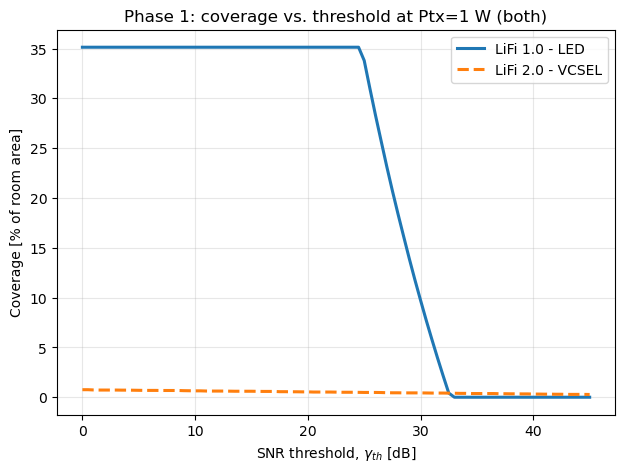

In [14]:
th_range_dB = np.linspace(0, 45, 91)  # SNR thresholds to sweep [dB]
cov_led_curve, cov_vcsel_curve = [], []
for th_dB in th_range_dB:
    g = 10**(th_dB / 10)  # threshold converted to linear scale
    cov_led_curve.append(100 * np.mean(SNR_led1 >= g))      # % of room area above threshold, LED
    cov_vcsel_curve.append(100 * np.mean(SNR_vcsel1 >= g))  # % of room area above threshold, VCSEL

fig, ax = plt.subplots(figsize=(7.2, 5))
ax.plot(th_range_dB, cov_led_curve, lw=2.2, label="LiFi 1.0 - LED")
ax.plot(th_range_dB, cov_vcsel_curve, lw=2.2, ls="--", label="LiFi 2.0 - VCSEL")
ax.set_xlabel(r"SNR threshold, $\gamma_{th}$ [dB]")
ax.set_ylabel("Coverage [% of room area]")
ax.set_title(f"Phase 1: coverage vs. threshold at Ptx={PTX_NORM:.0f} W (both)")
ax.legend()
ax.grid(alpha=.3)
plt.show()


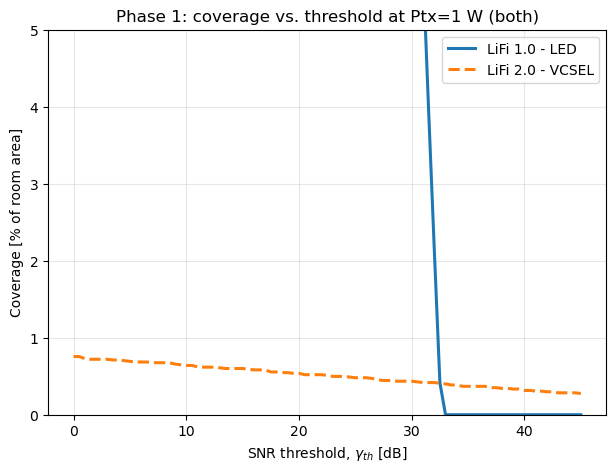

In [17]:
## misma figura pero con zoom 

th_range_dB = np.linspace(0, 45, 91)  # SNR thresholds to sweep [dB]
cov_led_curve, cov_vcsel_curve = [], []
for th_dB in th_range_dB:
    g = 10**(th_dB / 10)  # threshold converted to linear scale
    cov_led_curve.append(100 * np.mean(SNR_led1 >= g))      # % of room area above threshold, LED
    cov_vcsel_curve.append(100 * np.mean(SNR_vcsel1 >= g))  # % of room area above threshold, VCSEL

fig, ax = plt.subplots(figsize=(7.2, 5))
ax.plot(th_range_dB, cov_led_curve, lw=2.2, label="LiFi 1.0 - LED")
ax.plot(th_range_dB, cov_vcsel_curve, lw=2.2, ls="--", label="LiFi 2.0 - VCSEL")
ax.set_xlabel(r"SNR threshold, $\gamma_{th}$ [dB]")
ax.set_ylabel("Coverage [% of room area]")
ax.set_title(f"Phase 1: coverage vs. threshold at Ptx={PTX_NORM:.0f} W (both)")
ax.legend()
ax.grid(alpha=.3)
ax.set_ylim(0,5)
plt.show()

In [18]:


diff = np.array(cov_vcsel_curve) - np.array(cov_led_curve)
sign_changes = np.where(np.diff(np.sign(diff)) != 0)[0]

print("Crossing point(s) between the LED and VCSEL coverage-vs-threshold curves:")
for idx in sign_changes:
    if max(cov_led_curve[idx + 1], cov_vcsel_curve[idx + 1]) < 0.1:
        continue  # not a real crossing, both curves are already at zero coverage
    th1, th2 = th_range_dB[idx], th_range_dB[idx + 1]
    d1, d2 = diff[idx], diff[idx + 1]
    th_cross = th1 - d1 * (th2 - th1) / (d2 - d1)
    print(f"  ~{th_cross:4.1f} dB  (LED~{cov_led_curve[idx]:.1f}%, VCSEL~{cov_vcsel_curve[idx]:.1f}%)")

fov_disk_pct = 100 * np.pi * r_fov**2 / (ROOM_X * ROOM_Y)
print(f"\nShared FoV-disk geometric max coverage: {fov_disk_pct:5.1f}% of the room "
      "(both curves saturate at this value at low thresholds)")

# SNR at the FoV-disk edge @1W: 
d_edge = np.hypot(r_fov, dz)
Hl_edge = (m_led + 1) * APD / (2 * np.pi * d_edge**2) * np.cos(PSI_C)**m_led * np.cos(PSI_C) * G_CONC
wz_edge = W0 * np.sqrt(1 + (d_edge / zR)**2)
Hv_edge = 2 / (np.pi * wz_edge**2) * np.exp(-2 * r_fov**2 / wz_edge**2) * APD * G_CONC
print(f"SNR at the FoV-disk edge @ 1 W: LED = {10*np.log10((RHO*Hl_edge)**2/(N0*B1)):.1f} dB, "
      f"VCSEL = {10*np.log10((RHO*Hv_edge)**2/(N0*B2)):.1f} dB")

Crossing point(s) between the LED and VCSEL coverage-vs-threshold curves:
  ~32.5 dB  (LED~0.4%, VCSEL~0.4%)

Shared FoV-disk geometric max coverage:  35.4% of the room (both curves saturate at this value at low thresholds)
SNR at the FoV-disk edge @ 1 W: LED = 24.8 dB, VCSEL = -1896.5 dB


This shows how much of the room floor clears each possible quality bar. The LED starts at the FoV-disk maximum and holds it until the threshold gets demanding. The VCSEL never gets close to that maximum in the first place, since its own beam width, not the receiver's FoV, is what limits it (but the small area it does cover stays lit across a much wider range of thresholds, simply because its peak signal is so much stronger).

### 3.7 Phase 1 discussion

* **The LED covers its entire ~35% FoV-disk plateau at low thresholds, and only starts losing area past about 25 dB** (falling to half that area by ~28.5 dB). Its flat Lambertian pattern is what keeps the whole disk covered up to such demanding thresholds.

* **The VCSEL never reaches that 35% plateau at all: even at a 0 dB threshold, its coverage is only about 0.8% of the room.** Its own beam (about 12 cm across at the desk) is far narrower than the 1.68 m FoV disk, so the receiver's field of view is not what limits the VCSEL here - its own directivity is. That tiny covered area barely shrinks as the threshold rises (0.8% at 0 dB, still 0.3% at 40 dB), because the signal right at the beam axis is so strong that only extreme thresholds can knock it out.

* **The VCSEL's peak SNR (~70 dB) is now far above the LED's (~33 dB), and so is its peak channel gain (about 29 dB more at the center).** Concentrating the same 1 W into a beam only centimetres wide, instead of spreading it Lambertian-style across the room, is what buys that gain. Even after the VCSEL's 100x larger bandwidth adds 20 dB of extra noise power, its SNR advantage survives, and it converts into a peak rate of about 22 Gbit/s against the LED's 96 Mbit/s -- roughly 230x faster, at the one point where the VCSEL's beam actually lands.

**Phase 1 conclusion.** At equal power, the two technologies split the problem in opposite directions: the LED trades peak signal strength for area, covering over a third of the room at a modest rate everywhere within it; the VCSEL trades area for peak signal strength, delivering an extreme rate but only in a spot about the size of a small dinner plate. Neither number is "better" alone, since which one matters depends entirely on whether the goal is area or a point.

---

## 4. Phase 2: Realistic single-cell analysis

Here the question changes. Phase 1 asked "how do the channels compare", Phase 2 asks "what actually happens once each technology is limited by its own real constraints." So instead of the arbitrary 1 W for both, each transmitter now gets the power it should use in real life. 


### 4.1 LiFi 1.0 power - illuminance requirement

The LED power is obtained from an illuminance target: 500 lux, the standard EN 12464-1 value for office/reading tasks, and also the target used in the `[RIS-VLC]` reference paper (Sec. V). The same Lambertian model from Phase 1 is used, but now written in terms of illuminance instead of gain.

The $A_{PD}$ term cancels out because illuminance describes the light field itself, not any particular detector:

$$E_v(0) = K_{e/v}\cdot P_{tx}\cdot\frac{m+1}{2\pi d_z^2}\quad\Rightarrow\quad
P_{tx}=\frac{E_{target}}{E_v(0)/P_{tx}}$$

The `[RIS-VLC]` paper's own optimized benchmark (Fig. 15) uses 4 LEDs together reaching 500 lux average in a 4x4x3 m room, with about 82-90 W total (roughly 20-22 W per LED). The isolated LED used in this analysis needs somewhat more than that per-LED figure, which makes sense as in their case four LEDs share the work of lighting the room, so one LED on its own has to work harder.

> Here the power is set so the illuminance **averaged over the whole room** equals 500 lux, matching how EN 12464-1 and `[RIS-VLC]` actually define the target (an average over the task area), and the same convention already used for the LED power in the multi-cell notebook -- the two notebooks are now directly comparable on this number. The point directly below the Tx (the peak) ends up well above 500 lux; if instead only that single peak point had to hit the target, less power would be enough, shown as a comparison in the next cell.


In [ ]:
KE_V = 280.0          # luminous efficacy K_e/v [lm/W], [RIS-VLC] Table III
E_TARGET_LUX = 500.0  # illuminance target [lux], EN 12464-1 office value ([RIS-VLC] Sec. V)

# Illuminance from optical power, [RIS-VLC] eq. (25):  E_v = (K_e/v / A_PD) * P * H_LoS

# EN 12464-1 and [RIS-VLC] define 500 lux as a ROOM-AVERAGE over the task area, so that is
# used as the primary value here 

# this is the same convention already used for the LED power in
# the multi-cell notebook, so the two are now directly comparable

E_per_watt_room_avg = KE_V * np.mean(H_led_src) / APD  # average lux per watt, over the whole X,Y grid
PTX_LED_REALISTIC = E_TARGET_LUX / E_per_watt_room_avg  # LED power for the 500 lux room-average target [W]
print(f"LiFi 1.0 realistic power (single LED, {E_TARGET_LUX:.0f} lux room-average target): {PTX_LED_REALISTIC:.1f} W")


E_per_watt_boresight = KE_V * (m_led + 1) / (2 * np.pi * dz**2)  # lux produced per watt, directly below the tx
PTX_LED_PEAK = E_TARGET_LUX / E_per_watt_boresight                # LED power for a peak-only target [W]
print(f"For comparison -- LED power if only the PEAK point (directly below the Tx) had to hit "
      f"{E_TARGET_LUX:.0f} lux: {PTX_LED_PEAK:.1f} W ({PTX_LED_REALISTIC / PTX_LED_PEAK:.1f}x less than the "
      f"room-average value used everywhere else in this notebook)")


LiFi 1.0 realistic power (single LED, 500 lux room-average target): 84.7 W
For comparison -- LED power if only the PEAK point (directly below the Tx) had to hit 500 lux: 32.2 W (2.6x less than the room-average value used everywhere else in this notebook)


### 4.2 LiFi 2.0 power - eye safety IEC 60825-1

For the VCSEL, the transmit power is limited by eye-safety requirements.

Unlike LEDs, VCSELs are laser sources, meaning that the maximum optical power of a single emitter is constrained by the IEC 60825-1 laser safety standard. Consequently, a single VCSEL cannot operate at the same optical power as a LED.

To obtain a realistic value, the maximum eye-safe power is estimated following the methodology presented in `[Eye-Safety]`. This value is also compared with experimentally reported operating powers found in the literature (`[VCSEL-70Gbps]`), confirming that practical single-mode VCSELs typically operate in the milliwatt range.

Following `[Eye-Safety]`, the point-source Maximum Permissible Exposure (IEC 60825-1, near-IR, long exposure) is:

$$\text{MPE}(\lambda) = 10\,C_4\,C_7 \ \ [\text{W/m}^2], \qquad C_4=10^{0.002(\lambda-700)}$$

and the maximum eye-safe CW power of a single-mode Gaussian beam is (`[Eye-Safety]` eq. (36)):

$$P_{tx,max} = \frac{1}{\eta}\,\text{MPE}(\lambda)\,\pi r_p^2$$

where $\eta$ is the fraction of the beam's power that could enter a dilated pupil of radius $r_p$ at the hazard distance $z_{haz}$ (see Section 4.2.1 for the caveats on this estimate).

#### 4.2.1 Choosing a physically consistent beam waist

The beam waist $w_0$ is not only used for the eye-safety ceiling below: it sets the Rayleigh range $z_R$ and the beam radius $w(d)$ in the VCSEL channel model (Section 3.1), which feeds every VCSEL channel-gain map, SNR value and coverage number in this notebook, in both Phase 1 and Phase 2. It has to be chosen once, deliberately, rather than picked up implicitly wherever it first appears.

`[VCSEL-Precoding]` Table I lists $w_0 = 0.45\ \mu m$, but that value is smaller than the VCSEL's own wavelength $\lambda = 950\ nm$. The Gaussian-beam model used throughout this notebook requires $w_0 \gg \lambda$ (the paraxial regime), so $0.45\ \mu m$ sits outside where the model is actually valid: it gives an unrealistically large divergence, $\theta \approx \lambda/(\pi w_0) \approx 38°$ half-angle, far wider than a real VCSEL beam.

This notebook instead uses $w_0 = 5\ \mu m$ as the primary value everywhere, the same realistic waist that `[Eye-Safety]` itself uses in its own worked examples (Figs. 7, 9, 13, 16-18) - this is the same choice already used in the multi-cell notebook, for consistency between the two. At this value $w_0 \gg \lambda$ holds comfortably, the divergence half-angle drops to a physically reasonable $\theta \approx 3.5°$, and, as the next cell shows, the resulting eye-safe ceiling comes out close to the $5\ mW$ experimentally reported in `[VCSEL-70Gbps]`, instead of 45x above it.

The sub-wavelength $0.45\ \mu m$ value is not discarded, since it is what `[VCSEL-Precoding]` itself reports: Section 4.2.2 keeps it as an idealized sensitivity case, to check how much this notebook's conclusions actually depend on the choice of $w_0$.

In [96]:
def mpe_point_long_exposure(lam_nm):
    # IEC 60825-1 point-source MPE, near-IR, long exposure (t_ex > 10 s)
    # [Eye-Safety] Table 4:  MPE = 10 * C4 * C7 [W/m^2];  C4 = 10^(0.002(lam-700));  C7 = 1 for lam < 1150 nm
    C4 = 10**(0.002 * (lam_nm - 700))
    C7 = 1.0 if lam_nm < 1150 else 10**(0.018 * (lam_nm - 1150))
    return 10 * C4 * C7  # MPE [W/m^2]

assert abs(mpe_point_long_exposure(850) - 19.95) < 0.1  # [Eye-Safety]: ~20 W/m^2 at 850 nm (matches the tutorial)
MPE_950 = mpe_point_long_exposure(950)

def eye_safe_ptx(w0, lam, rp=3.5e-3):
    # max eye-safe CW power for a single-mode Gaussian VCSEL beam, [Eye-Safety] Algorithm 1 + eq. (36)
    # w0: beam waist [m], lam: wavelength [m], rp: worst-case dilated pupil radius [m]
    # rp = 3.5 mm -> 7 mm limiting aperture ([Eye-Safety] Sec. II-D)

    zR_ = np.pi * w0**2 / lam       # Rayleigh range, [VCSEL-Precoding] eq. (2) / [Eye-Safety] eq. (5)
    theta_div = lam / (np.pi * w0)  # beam divergence half-angle, [Eye-Safety] eq. (8)
    d86 = (np.pi * w0 / lam) * np.sqrt(-2 * rp**2 / np.log(1 - 0.86))  # distance where the pupil catches 86% of the beam power [m]
    # [Eye-Safety] Algorithm 1, step 1
    if 2 * theta_div > 0.092 and d86 < 0.1:
        zhaz = 0.1  # hazard distance capped at 10 cm for wide-divergence beams ([Eye-Safety] Alg. 1)
    else:
        alpha = 2 * np.arctan(w0 / d86)
        zhaz = 2 * w0 / 0.0021 if alpha < 1.5e-3 else 9.2 * np.pi * w0 / (2 * lam)  # [Eye-Safety] Alg. 1, step 9/12
    Wzhaz = w0 * np.sqrt(1 + (zhaz / zR_)**2)  # beam radius at the hazard distance, [Eye-Safety] eq. (4a)
    eta = 1 - np.exp(-2 * rp**2 / Wzhaz**2)    # fraction of beam power entering the pupil
    return (1 / eta) * mpe_point_long_exposure(lam * 1e9) * np.pi * rp**2, zhaz, eta  # Pt,max, [Eye-Safety] eq. (36)

PTX_VCSEL_EYESAFE, zhaz, eta = eye_safe_ptx(W0, LAMBDA)
PTX_VCSEL_EXPERIMENTAL = 5e-3  # [VCSEL-70Gbps] Table I (Pt = 4.26 / 4.95 mW) / abstract ("below 5 mW"), 940 nm

print(f"MPE(950nm, point source, long exposure) = {MPE_950:.1f} W/m^2")
print(f"Theoretical eye-safe ceiling (single bare VCSEL, w0={W0*1e6:.2f} um): {PTX_VCSEL_EYESAFE*1e3:.1f} mW")
print(f"Real experimental operating power ([VCSEL-70Gbps], Kazemi et al. 2025): {PTX_VCSEL_EXPERIMENTAL*1e3:.1f} mW")
print(f"\nRatio LED/VCSEL realistic power: {PTX_LED_REALISTIC/PTX_VCSEL_EYESAFE:.0f}x (vs. eye-safety ceiling) "
      f"/ {PTX_LED_REALISTIC/PTX_VCSEL_EXPERIMENTAL:.0f}x (vs. experimental value)")


MPE(950nm, point source, long exposure) = 31.6 W/m^2
Theoretical eye-safe ceiling (single bare VCSEL, w0=5.00 um): 2.5 mW
Real experimental operating power ([VCSEL-70Gbps], Kazemi et al. 2025): 5.0 mW

Ratio LED/VCSEL realistic power: 33983x (vs. eye-safety ceiling) / 16943x (vs. experimental value)


#### 4.2.2 Sensitivity to the beam waist

$w_0 = 5\ \mu m$ is used as the primary value throughout this notebook (Section 4.2.1), but it is worth checking how much the conclusions would change with a different, idealized waist instead -- in particular the sub-wavelength $0.45\ \mu m$ that `[VCSEL-Precoding]` Table I literally states, kept here only as a sensitivity case rather than as the notebook's main configuration.

As a further data point, `[VCSEL-70Gbps]` reports a measured divergence half-angle (defined at the 86%-power beam radius) of $12.7°\text{-}15.3°$; using the midpoint $\theta\approx14°$ and inverting $\theta\approx\lambda/(\pi w_0)$ gives a third, experimentally-grounded waist,

$$w_{0,\text{alt}} = \frac{\lambda}{\pi\theta} \approx 1.24\ \mu m.$$

This mixes two different divergence-angle definitions (the 86%-power one reported experimentally vs. the $1/e^2$ Gaussian one used by the model), so it is only an order-of-magnitude cross-check, not a substitute for the primary $5\ \mu m$ value.

In [ ]:
# sensitivity check: how much would the notebook's conclusions change with a different,
# idealized w0, instead of the w0 = 5 um used as the primary value everywhere else?

THETA_DIV_EXP_DEG = 14.0  # [VCSEL-70Gbps]: midpoint of the reported 12.7-15.3 deg range
W0_ALT = LAMBDA / (np.pi * np.deg2rad(THETA_DIV_EXP_DEG))  # inverting theta = lambda/(pi*w0)

def vcsel_channel(w0):
    # same Section 3.1 formulas, recomputed for a different w0 only
    zR_ = np.pi * w0**2 / LAMBDA
    wz_ = w0 * np.sqrt(1 + (d3d / zR_)**2)
    H_src = 2 / (np.pi * wz_**2) * np.exp(-2 * r0**2 / wz_**2) * APD
    return np.where(in_fov, H_src * G_CONC, 0.0)

sensitivity_cases = [
    ("5.00 um (primary, used everywhere else)", W0),
    ("0.45 um (idealized, [VCSEL-Precoding] Table I)", 0.45e-6),
    (f"{W0_ALT*1e6:.2f} um ([VCSEL-70Gbps]-derived)", W0_ALT),
]

print(f"{'w0 case':48s} {'eye-safe Ptx':>14s}   {'Phase-2 peak SNR':>16s}")
for label, w0_case in sensitivity_cases:
    Ptx_eyesafe_case, _, _ = eye_safe_ptx(w0_case, LAMBDA)
    H_case = vcsel_channel(w0_case)
    peak_snr_dB = 10 * np.log10(np.nanmax((RHO * Ptx_eyesafe_case * H_case)**2 / (N0 * B2)))
    print(f"{label:48s} {Ptx_eyesafe_case*1e3:10.2f} mW   {peak_snr_dB:14.1f} dB")

w0 case                                            eye-safe Ptx   Phase-2 peak SNR
5.00 um (primary, used everywhere else)                2.49 mW             18.3 dB
0.45 um (idealized, [VCSEL-Precoding] Table I)       224.92 mW             15.7 dB
1.24 um ([VCSEL-70Gbps]-derived)                      30.27 mW             15.9 dB


Across all three waists, the eye-safe ceiling swings by more than two orders of magnitude (2.5 mW to 224.9 mW), yet the Phase-2 peak SNR only moves between about 15.7 dB and 18.3 dB -- always below the 20 dB coverage threshold used throughout this notebook. A narrower waist gives a higher eye-safe power but also a wider, weaker beam, and a wider waist gives a tighter, stronger beam but a lower eye-safe power; the two effects trade off against each other closely enough that the headline conclusion of Section 4.3 (a single VCSEL misses the coverage threshold even at its single best point) holds for every waist considered here, not just the primary $5\ \mu m$ value.

### 4.3 Coverage under realistic power

Same SNR-threshold coverage as before, but now with each technology's own realistic power 


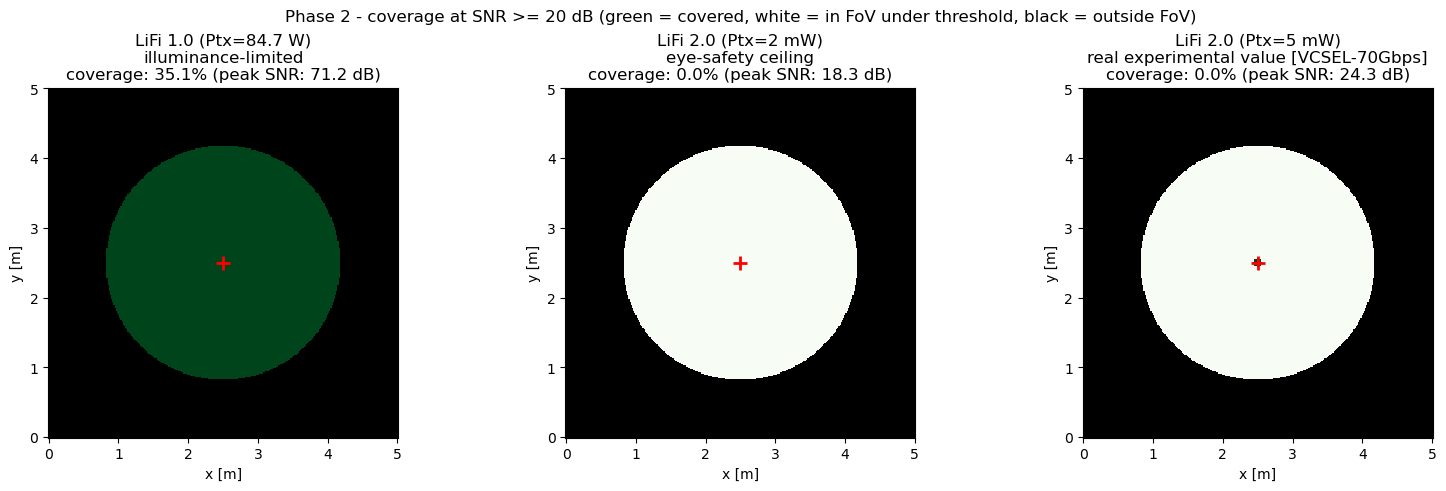

In [98]:
_, _, SNR_led_re, SNR_vcsel_eyesafe, _, R_vcsel_eyesafe = snr_rate(PTX_LED_REALISTIC, PTX_VCSEL_EYESAFE)
_, _, _, SNR_vcsel_exp, _, R_vcsel_exp = snr_rate(PTX_LED_REALISTIC, PTX_VCSEL_EXPERIMENTAL)

GAMMA_TH_DB = 20.0  # SNR threshold used to define "covered" [dB]
gamma_th = 10**(GAMMA_TH_DB / 10)
cov_led_re = SNR_led_re >= gamma_th # coverage map, LED at realistic power
cov_vcsel_eyesafe_map = SNR_vcsel_eyesafe >= gamma_th # coverage map, VCSEL at the eye-safety ceiling
cov_vcsel_exp_map = SNR_vcsel_exp >= gamma_th  # coverage map, VCSEL at the experimental power

cov_cmap = plt.cm.Greens.copy()
cov_cmap.set_bad("black")
# unified receiver: the same FoV mask (in_fov, from Section 3.1) applies to both technologies

def cov_black_outside(cov, in_fov):
    return np.where(in_fov, cov.astype(float), np.nan)  

# peak SNR per scenario, so a 0%-coverage panel still shows how close (or far) it got from the threshold
peak_snr_led_dB = 10 * np.log10(np.nanmax(SNR_led_re))
peak_snr_eyesafe_dB = 10 * np.log10(np.nanmax(SNR_vcsel_eyesafe))
peak_snr_exp_dB = 10 * np.log10(np.nanmax(SNR_vcsel_exp))

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), constrained_layout=True)
panels = [
    (cov_black_outside(cov_led_re, in_fov), cov_led_re, peak_snr_led_dB,
     f"LiFi 1.0 (Ptx={PTX_LED_REALISTIC:.1f} W)\nilluminance-limited"),
    (cov_black_outside(cov_vcsel_eyesafe_map, in_fov), cov_vcsel_eyesafe_map, peak_snr_eyesafe_dB,
     f"LiFi 2.0 (Ptx={PTX_VCSEL_EYESAFE*1e3:.0f} mW)\neye-safety ceiling"),
    (cov_black_outside(cov_vcsel_exp_map, in_fov), cov_vcsel_exp_map, peak_snr_exp_dB,
     f"LiFi 2.0 (Ptx={PTX_VCSEL_EXPERIMENTAL*1e3:.0f} mW)\nreal experimental value [VCSEL-70Gbps]"),
]
for ax, (cov_disp, cov_bool, peak_snr_dB, title) in zip(axes, panels):
    ax.pcolormesh(X, Y, cov_disp, shading="auto", cmap=cov_cmap, vmin=0, vmax=1)
    ax.plot(*TX_POS[:2], "r+", markersize=10, mew=2)
    ax.set_title(f"{title}\ncoverage: {100*cov_bool.mean():.1f}% (peak SNR: {peak_snr_dB:.1f} dB)")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")
fig.suptitle(f"Phase 2 - coverage at SNR >= {GAMMA_TH_DB:.0f} dB "
             "(green = covered, white = in FoV under threshold, black = outside FoV)")
plt.show()


Green means "good enough signal", white means "in view but too weak", and black means "the receiver can't see that area at all". At realistic power levels, the single LED covers about a third of the room, while the single VCSEL barely registers: at its eye-safety ceiling it fails to reach the required quality anywhere, and even at the higher experimental power it only clears the bar in a pinprick under 0.05% of the room, right at the beam's own center. Eye-safety rules force the laser to use far less power than a light bulb is allowed to, and its own narrow beam then confines whatever power it does get to a tiny spot.

Taking realistic power levels into account, the single LED covers just over a third of the room; that is essentially its **entire FoV disk**, so at this power the LED is FoV-limited rather than power-limited. The single VCSEL tells a different story at each power anchor: at its eye-safety ceiling (2.5 mW) it covers 0% of the room, since its peak SNR of ~18.3 dB never reaches the 20 dB bar anywhere; at the higher experimental power (5 mW) its peak SNR does clear the bar, at ~24.3 dB, but only within the beam's own narrow footprint, covering a mere 0.05% of the room -- effectively a single bright point rather than any real coverage.

### 4.4 Summary table and energy efficiency

Energy efficiency is reported in bit/J, the achievable rate per watt of transmit power:

$$\text{EE} = \frac{R}{P_{tx}}$$

Note that a very small $P_{tx}$ can make EE look enormous even at negligible coverage, so this metric is only meaningful read together with the coverage figure next to it, not in isolation.

The table also reports **area spectral efficiency** (ASE), the achievable rate spread over the whole room floor rather than over transmit power:

$$\text{ASE} = \frac{\overline{R}}{A_{room}}$$

where $\overline{R}$ is the mean rate over the receiver grid (points outside the receiver's FoV count as zero) and $A_{room}$ is the room floor area. This is the same metric used for a single AP ($N_{AP}=1$) in the multi-cell notebook, so the two are directly comparable. It is what lets a technology that wins on *peak* rate (Section 3.7) be checked against one that wins on *coverage*, on a single number: a high peak rate concentrated in a tiny spot and a modest rate spread over a third of the room can land very differently on ASE, which is exactly the point of reporting it.

In [99]:
import pandas as pd

R_led_re = 0.5 * B1 * np.log2(1 + K_BOUND * SNR_led_re)  # rate map at realistic LED power (not kept by the cell above)

def ee_peak_avg(rate_map, Ptx):
    # (peak, avg) energy efficiency in bit/J, from a rate map [bit/s] and Ptx [W]
    peak = np.nanmax(rate_map) / Ptx
    avg = np.nanmean(np.nan_to_num(rate_map, nan=0.0)) / Ptx
    return peak, avg

ROOM_AREA = ROOM_X * ROOM_Y  # [m^2]

def spatial_ase(rate_map):
    # area spectral efficiency [bit/s/m^2]: mean rate over the whole room (NaN, i.e. outside
    # the FoV, counts as zero), divided by room area -- same definition as N_AP=1 in the
    # multi-cell notebook, so single- and multi-cell ASE numbers are directly comparable
    return np.nanmean(np.nan_to_num(rate_map, nan=0.0)) / ROOM_AREA

rows = []
def add_row(name, Ptx, SNR_map, R_map, cov_frac):
    ee_peak, ee_avg = ee_peak_avg(R_map, Ptx)
    rows.append({
        "Scenario": name,
        "Ptx": f"{Ptx:.4g} W",
        "Peak SNR [dB]": round(10 * np.log10(np.nanmax(SNR_map)), 1),
        "Peak rate [Mbit/s]": round(np.nanmax(R_map) / 1e6, 1),
        f"Coverage@{GAMMA_TH_DB:.0f}dB [%]": round(100 * cov_frac, 1),
        "ASE [Mbit/s/m2]": round(spatial_ase(R_map) / 1e6, 3),
        "EE peak [Mbit/J]": round(ee_peak / 1e6, 2),
        "EE avg [Mbit/J]": round(ee_avg / 1e6, 4),
    })

add_row("LiFi 1.0 (Phase 1, norm. 1 W)",     PTX_NORM,               SNR_led1,          R_led1,          np.mean(SNR_led1 >= gamma_th))
add_row("LiFi 2.0 (Phase 1, norm. 1 W)",     PTX_NORM,               SNR_vcsel1,        R_vcsel1,        np.mean(SNR_vcsel1 >= gamma_th))
add_row("LiFi 1.0 (Phase 2, realistic)",     PTX_LED_REALISTIC,      SNR_led_re,        R_led_re,        cov_led_re.mean())
add_row("LiFi 2.0 (Phase 2, eye-safety)",    PTX_VCSEL_EYESAFE,      SNR_vcsel_eyesafe, R_vcsel_eyesafe, cov_vcsel_eyesafe_map.mean())
add_row("LiFi 2.0 (Phase 2, experimental)",  PTX_VCSEL_EXPERIMENTAL, SNR_vcsel_exp,     R_vcsel_exp,     cov_vcsel_exp_map.mean())

summary_df = pd.DataFrame(rows)
summary_df

,Scenario,Ptx,Peak SNR [dB],Peak rate [Mbit/s],Coverage@20dB [%],ASE [Mbit/s/m2],EE peak [Mbit/J],EE avg [Mbit/J]
0,"LiFi 1.0 (Phase 1, norm. 1 W)",1 W,32.6,96.3,35.1,1.154,96.30,28.8573
1,"LiFi 2.0 (Phase 1, norm. 1 W)",1 W,70.3,22156.7,0.5,3.191,22156.71,79.7776
2,"LiFi 1.0 (Phase 2, realistic)",84.71 W,71.2,224.4,35.1,2.954,2.65,0.8716
3,"LiFi 2.0 (Phase 2, eye-safety)",0.002493 W,18.3,4909.5,0.0,0.196,1969467.31,1962.3442
4,"LiFi 2.0 (Phase 2, experimental)",0.005 W,24.3,6881.3,0.0,0.347,1376257.19,1736.1581


The ASE column gives a first, quantified answer to the area-vs-point question raised in Section 3.7: at Phase 1's equal, unrealistic 1 W, the VCSEL actually wins on ASE too (3.2 vs 1.2 Mbit/s/m^2), since its peak rate is high enough to outweigh its tiny footprint even when averaged over the whole room. Phase 2 flips that: on realistic power, the LED's ASE more than doubles (2.95 Mbit/s/m^2), while the VCSEL's collapses to a few tenths, since the eye-safety ceiling removes exactly the power that made its peak rate so large in the first place. ASE is what will matter most once several access points are deployed side by side in the multi-cell notebook, since it is the metric that keeps a technology from winning simply by using more transmitters or more power.

### 4.5 Spectral consideration - wavelength-dependent responsivity

Everywhere above both technologies use the same fixed responsivity $\rho = 1$ A/W, which is what isolates the channel and power effects. In reality the photodiode responsivity depends on the wavelength,

$$\rho(\lambda) = \eta\,\frac{q\,\lambda}{h\,c},$$

and for a silicon photodiode it grows with $\lambda$ up to the ~1100 nm cut-off. LiFi 1.0 emits across the visible band, while LiFi 2.0 emits in the near-IR (~950 nm), so at the same received optical power the VCSEL produces more photocurrent — the near-IR link benefits from the receiver's higher responsivity.

This is a receiver property, so it does not change any Phase 1/2 conclusion, but since $\text{SNR}\propto(\rho P_r)^2$ it does shift the SNR. I keep $\rho = 1$ as the baseline and only quantify the effect here with representative datasheet values.

In [100]:
Q_E = 1.602e-19    # electron charge [C]
H_PLANCK = 6.626e-34  # Planck constant [J*s]
C_LIGHT = 3e8      # speed of light [m/s]

def responsivity_ideal(lam_nm, eta=1.0):
    # ideal photodiode responsivity rho = eta*q*lambda/(h*c) [A/W]
    lam = lam_nm * 1e-9
    return eta * Q_E * lam / (H_PLANCK * C_LIGHT)

# representative silicon PIN photodiode values (datasheet-dependent)
RHO_LED = 0.4    # ~550 nm effective, visible band (LiFi 1.0) [A/W]
RHO_VCSEL = 0.6  # ~950 nm (LiFi 2.0) [A/W]

print(f"ideal rho (eta=1): @550nm = {responsivity_ideal(550):.2f} A/W, @950nm = {responsivity_ideal(950):.2f} A/W")
print(f"representative rho: LED (visible) = {RHO_LED} A/W, VCSEL (950 nm) = {RHO_VCSEL} A/W")

# effect on SNR: SNR ~ (rho*Pr)^2
d_snr_led_dB = 20 * np.log10(RHO_LED / RHO)
d_snr_vcsel_dB = 20 * np.log10(RHO_VCSEL / RHO)
print(f"\nSNR shift vs the rho=1 baseline: LED {d_snr_led_dB:+.1f} dB, VCSEL {d_snr_vcsel_dB:+.1f} dB")
print(f"Net relative shift in favour of the VCSEL: {d_snr_vcsel_dB - d_snr_led_dB:+.1f} dB")

# recompute Phase 2 coverage with the wavelength-dependent responsivities (same [RIS-VLC] eq. (12) SNR)
SNR_led_rho = (RHO_LED * PTX_LED_REALISTIC * H_led)**2 / (N0 * B1)
SNR_vcsel_rho = (RHO_VCSEL * PTX_VCSEL_EYESAFE * H_vcsel)**2 / (N0 * B2)
print(f"\nPhase 2 coverage @ {GAMMA_TH_DB:.0f} dB with wavelength-dependent rho:")
print(f"  LiFi 1.0 (rho={RHO_LED}):   {100*np.mean(SNR_led_rho >= gamma_th):.1f}%  (was {100*cov_led_re.mean():.1f}% at rho=1)")
print(f"  LiFi 2.0 (rho={RHO_VCSEL}): {100*np.mean(SNR_vcsel_rho >= gamma_th):.1f}%  (was {100*cov_vcsel_eyesafe_map.mean():.1f}% at rho=1)")
print("\n-> the +3.5 dB relative gain for the VCSEL doesn't flip the picture: a single VCSEL is still power-limited.")


ideal rho (eta=1): @550nm = 0.44 A/W, @950nm = 0.77 A/W
representative rho: LED (visible) = 0.4 A/W, VCSEL (950 nm) = 0.6 A/W

SNR shift vs the rho=1 baseline: LED -8.0 dB, VCSEL -4.4 dB
Net relative shift in favour of the VCSEL: +3.5 dB

Phase 2 coverage @ 20 dB with wavelength-dependent rho:
  LiFi 1.0 (rho=0.4):   35.1%  (was 35.1% at rho=1)
  LiFi 2.0 (rho=0.6): 0.0%  (was 0.0% at rho=1)

-> the +3.5 dB relative gain for the VCSEL doesn't flip the picture: a single VCSEL is still power-limited.


### 4.6 Sensitivity to the receiver FoV and the coverage threshold

Every conclusion in Phase 2 was drawn at one specific receiver FoV ($\Psi_c = 40°$) and one specific coverage threshold ($\gamma_{th} = 20$ dB). Neither value is fundamental -- $\Psi_c$ depends on the photodiode and any concentrator fitted to it (Section 3.1), and $\gamma_{th}$ just depends on what "good enough" is taken to mean. This section checks how much of Phase 2's picture survives if those choices are changed.

**Receiver FoV.** Widening $\Psi_c$ lets the receiver "see" a bigger disk on the desk plane ($r_\text{FoV}=\Delta z\tan\Psi_c$), but the concentrator gain $G=n^2/\sin^2\Psi_c$ (Section 3.1) falls at the same time, since a wider acceptance angle needs a weaker lens. Both technologies use the same receiver, so both feel this trade-off identically.

In [101]:
# sensitivity check: recompute the Phase-2 channel and coverage for a few receiver FoV values,
# keeping every other parameter (including Ptx) fixed at its Phase-2 value
def channel_at_fov(psi_c_deg):
    psi_c_ = np.deg2rad(psi_c_deg)
    g_conc_ = N_LENS**2 / np.sin(psi_c_)**2
    in_fov_ = theta <= psi_c_
    r_fov_ = dz * np.tan(psi_c_)
    H_led_ = np.where(in_fov_, H_led_src * g_conc_, 0.0)
    H_vcsel_ = np.where(in_fov_, H_vcsel_src * g_conc_, 0.0)
    return r_fov_, g_conc_, H_led_, H_vcsel_

print(f"{'Psi_c':>7s} {'r_FoV':>7s} {'G_conc':>7s} | {'LED Pr':>9s} {'LED SNR':>9s} {'LED cov':>9s} | "
      f"{'VCSEL Pr':>10s} {'VCSEL SNR':>10s} {'VCSEL cov':>10s}")
for psi_deg in [20, 40, 60]:
    r_fov_s, g_conc_s, H_led_s, H_vcsel_s = channel_at_fov(psi_deg)
    Pr_led_s = PTX_LED_REALISTIC * H_led_s
    Pr_vcsel_s = PTX_VCSEL_EYESAFE * H_vcsel_s
    SNR_led_s = (RHO * Pr_led_s)**2 / (N0 * B1)
    SNR_vcsel_s = (RHO * Pr_vcsel_s)**2 / (N0 * B2)
    cov_led_s = 100 * np.mean(SNR_led_s >= gamma_th)
    cov_vcsel_s = 100 * np.mean(SNR_vcsel_s >= gamma_th)
    print(f"{psi_deg:5.0f} deg {r_fov_s:5.2f} m {g_conc_s:6.3f} | "
          f"{np.nanmax(Pr_led_s)*1e3:7.3f} mW {10*np.log10(np.nanmax(SNR_led_s)):7.1f} dB {cov_led_s:7.1f} % | "
          f"{np.nanmax(Pr_vcsel_s)*1e3:8.4f} mW {10*np.log10(np.nanmax(SNR_vcsel_s)):8.1f} dB {cov_vcsel_s:8.2f} %"
          + (" (peak below threshold)" if np.nanmax(SNR_vcsel_s) < gamma_th else ""))

  Psi_c   r_FoV  G_conc |    LED Pr   LED SNR   LED cov |   VCSEL Pr  VCSEL SNR  VCSEL cov


   20 deg  0.73 m 19.234 |   9.050 mW    82.1 dB     6.6 % |   0.2047 mW     29.2 dB     0.10 %
   40 deg  1.68 m  5.446 |   2.562 mW    71.2 dB    35.1 % |   0.0579 mW     18.3 dB     0.00 % (peak below threshold)
   60 deg  3.46 m  3.000 |   1.411 mW    66.0 dB    99.9 % |   0.0319 mW     13.1 dB     0.00 % (peak below threshold)


**Coverage threshold.** The 20 dB bar used throughout this notebook is only one point on a continuum; Section 3.6 already swept it in Phase 1, so this repeats the same idea directly on the Phase-2, realistic-power maps.

In [102]:
# sensitivity check: coverage at a few thresholds, reusing the Phase-2 SNR maps already computed
print(f"{'Threshold':>10s} | {'LED coverage':>13s} | {'VCSEL coverage (eye-safe)':>27s} | {'VCSEL coverage (experimental)':>30s}")
for th_dB in [10, 20, 30]:
    g = 10**(th_dB / 10)
    cov_led_th = 100 * np.mean(SNR_led_re >= g)
    cov_vcsel_eyesafe_th = 100 * np.mean(SNR_vcsel_eyesafe >= g)
    cov_vcsel_exp_th = 100 * np.mean(SNR_vcsel_exp >= g)
    print(f"{th_dB:8.0f} dB | {cov_led_th:11.1f} % | {cov_vcsel_eyesafe_th:25.2f} % | {cov_vcsel_exp_th:28.2f} %")

 Threshold |  LED coverage |   VCSEL coverage (eye-safe) |  VCSEL coverage (experimental)
      10 dB |        35.1 % |                      0.09 % |                         0.16 %
      20 dB |        35.1 % |                      0.00 % |                         0.05 %
      30 dB |        35.1 % |                      0.00 % |                         0.00 %


Both sensitivities tell a consistent story. The receiver FoV moves the LED's headline number a great deal: its coverage swings from 6.6% at $\Psi_c=20°$ to 99.9% at $\Psi_c=60°$, so the "35%" quoted throughout this notebook is very much a property of the 40° choice, not a fixed fact about the LED. The VCSEL's story is far more stable: its coverage stays at essentially 0% across the same range (peaking at only 0.10% at the narrowest FoV, where the strongest concentrator gain briefly helps), because its own beam width, not the receiver's FoV, is what limits it -- the same conclusion from Section 3.3, holding up under a 3x range of $\Psi_c$.

The coverage threshold moves things much less: the LED holds its full ~35% disk from 10 dB up to 30 dB, since Phase 2's realistic power gives it enough SNR headroom that only much harder thresholds would start eating into it (Section 3.7 shows the same pattern in Phase 1). The VCSEL stays near 0% throughout, only picking up a fraction of a percent at the most lenient 10 dB bar.

Neither sensitivity changes this notebook's central conclusion, that a single VCSEL is coverage-limited by its own directivity rather than by any of these secondary choices, but the LED's specific numbers should be read as conditional on the $\Psi_c=40°$ and $\gamma_{th}=20$ dB choices made in Section 3.1 and Section 4.3, not as fixed properties of the technology.

---

## 5 Summary: LiFi 1.0 vs LiFi 2.0 so far

The table below closes the single-cell analysis with one row per metric, using each technology's Phase 2 realistic-power scenario (LED at its illuminance-driven power, VCSEL at its eye-safety ceiling) -- the same numbers computed throughout Sections 3-4, just collected in one place.

In [106]:
final_comparison_df = pd.DataFrame({
    "Metric": [
        "Channel model",
        "Directivity",
        "Peak channel gain, Phase 1 @ 1 W [dB]",
        "Peak rate, Phase 2 realistic power [Mbit/s]",
        f"Coverage @ {GAMMA_TH_DB:.0f} dB, Phase 2 realistic power [%]",
        "Area spectral efficiency, Phase 2 realistic power [Mbit/s/m2]",
        "Transmit power, Phase 2 realistic power",
    ],
    "LiFi 1.0 (LED)": [
        "Lambertian [RIS-VLC] eq. (1)",
        "Low (wide lobe, spreads over the whole room)",
        f"{10 * np.log10(np.nanmax(H_led)):.1f}",
        f"{np.nanmax(R_led_re) / 1e6:.1f}",
        f"{100 * cov_led_re.mean():.1f}",
        f"{spatial_ase(R_led_re) / 1e6:.2f}",
        f"{PTX_LED_REALISTIC:.1f} W",
    ],
    "LiFi 2.0 (VCSEL, eye-safe)": [
        "Gaussian beam [VCSEL-Precoding] eqs. (2)-(8)",
        f"High ({wz_boresight * 100:.0f} cm beam radius at the desk)",
        f"{10 * np.log10(np.nanmax(H_vcsel)):.1f}",
        f"{np.nanmax(R_vcsel_eyesafe) / 1e6:.1f}",
        f"{100 * cov_vcsel_eyesafe_map.mean():.2f}",
        f"{spatial_ase(R_vcsel_eyesafe) / 1e6:.3f}",
        f"{PTX_VCSEL_EYESAFE * 1e3:.2f} mW",
    ],
})
print(f"For reference, at the experimental {PTX_VCSEL_EXPERIMENTAL*1e3:.0f} mW anchor instead: "
      f"peak rate {np.nanmax(R_vcsel_exp)/1e6:.1f} Mbit/s, coverage {100*cov_vcsel_exp_map.mean():.2f}%, "
      f"ASE {spatial_ase(R_vcsel_exp)/1e6:.3f} Mbit/s/m2.")
final_comparison_df

For reference, at the experimental 5 mW anchor instead: peak rate 6881.3 Mbit/s, coverage 0.05%, ASE 0.347 Mbit/s/m2.


,Metric,LiFi 1.0 (LED),"LiFi 2.0 (VCSEL, eye-safe)"
0,Channel model,Lambertian [RIS-VLC] eq. (1),Gaussian beam [VCSEL-Precoding] eqs. (2)-(8)
1,Directivity,"Low (wide lobe, spreads over the whole room)",High (12 cm beam radius at the desk)
2,"Peak channel gain, Phase 1 @ 1 W [dB]",-45.2,-16.3
3,"Peak rate, Phase 2 realistic power [Mbit/s]",224.4,4909.5
4,"Coverage @ 20 dB, Phase 2 realistic power [%]",35.1,0.00
5,"Area spectral efficiency, Phase 2 realistic po...",2.95,0.196
6,"Transmit power, Phase 2 realistic power",84.7 W,2.49 mW


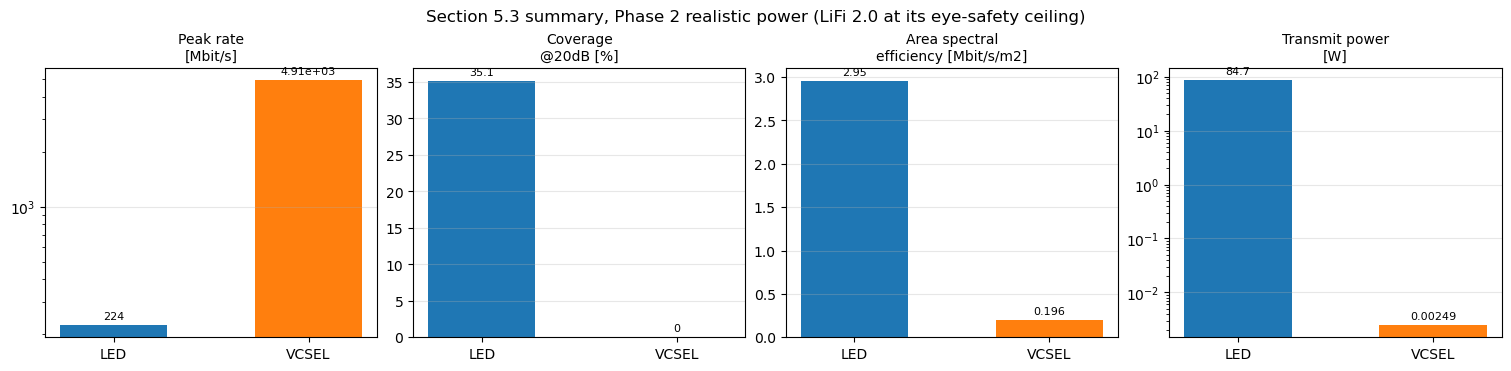

In [107]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), constrained_layout=True)
bar_specs = [
    ("Peak rate\n[Mbit/s]", np.nanmax(R_led_re) / 1e6, np.nanmax(R_vcsel_eyesafe) / 1e6, True),
    (f"Coverage\n@{GAMMA_TH_DB:.0f}dB [%]", 100 * cov_led_re.mean(), 100 * cov_vcsel_eyesafe_map.mean(), False),
    ("Area spectral\nefficiency [Mbit/s/m2]", spatial_ase(R_led_re) / 1e6, spatial_ase(R_vcsel_eyesafe) / 1e6, False),
    ("Transmit power\n[W]", PTX_LED_REALISTIC, PTX_VCSEL_EYESAFE, True),
]
colors = ["tab:blue", "tab:orange"]
for ax, (label, led_val, vcsel_val, log_scale) in zip(axes, bar_specs):
    bars = ax.bar(["LED", "VCSEL"], [led_val, vcsel_val], color=colors, width=0.55)
    if log_scale:
        ax.set_yscale("log")
    ax.set_title(label, fontsize=10)
    ax.bar_label(bars, fmt="%.3g", fontsize=8, padding=3)
    ax.grid(alpha=.3, axis="y")
fig.suptitle("Section 5.3 summary, Phase 2 realistic power (LiFi 2.0 at its eye-safety ceiling)")
plt.show()

Read as a single row each, the two technologies look almost like different tools entirely: the LED wins on every coverage-related metric, the VCSEL wins by orders of magnitude on peak rate and on transmit power (it needs thousands of times less), and area spectral efficiency is close between them only because the VCSEL's huge peak rate is averaged over a footprint that is otherwise nearly empty. None of this is a flaw in either technology -- it is the direct, measured consequence of directivity (Section 3) and of what each one's power budget is actually for (Section 4.1-4.2), and it is exactly the tension the multi-cell notebook picks up next: can either technology's weak metric be fixed by *deploying more of it*?

## 6. Transition to the multi-cell analysis

Bundling every VCSEL at the same point isn't a realistic array though. It only produces a single bright spot instead of uniform coverage, it can't serve more than one user at a time since every element points at the same place, and packing that many lasers together may no longer be eye-safe as a bundle.

This is exactly the gap from `[VCSEL-Precoding]`: an array distributed over the ceiling, precoded so that different (possibly overlapping) subsets of elements serve different users at once, instead of every element aiming at the same spot.

The next stage moves from this single-transmitter analysis to a multi-cell one, to see what a spatially distributed, precoded array actually achieves for coverage uniformity and multi-user capacity, not just for raw single-point power.
